# Tests

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!pip install -e src/ &>/dev/null

In [ ]:
import numpy as np

from src.channels import AWGNChannel, BECChannel
from src.core import PolarCode, PolarEncoder, awgn_frozen_set, bec_frozen_set, sc_decode, sc_decode_llr, bp_decode, bpl_decode, scl_decode

In [ ]:
N, K = 128, 64

CHANNEL: str = "BEC" #*"BEC" or "AWGN"
CHANNEL_CONFIGS = {
    #*at eps <= 0.2 every decoder scores 100% and the histograms collapse
    "BEC":  {"param": 0.30, "cls": BECChannel, "frozen_set": bec_frozen_set, "param_name": "epsilon"},
    #*the dB here is really Es/N0: AWGNChannel fixes Es = 1 and ignores the rate, so at
    #*R = 1/2 the equivalent Eb/N0 is 3 dB higher (-1.5 dB Es/N0 = +1.5 dB Eb/N0)
    "AWGN": {"param": -1.50, "cls": AWGNChannel, "frozen_set": awgn_frozen_set, "param_name": "Es/N0 (dB)"}, #*(higher = better)
}
config = CHANNEL_CONFIGS[CHANNEL]
CHANNEL_PARAM: float = config["param"]

ITERATIONS: int = 50 #*number of experiments, i.e. of points in each distribution
SAMPLES: int = 100 #*random us drawn per experiment (2**K cannot be enumerated at K=64)
ITER_CAP: int = 50 #*BP/BPL converge quickly or never, so a bigger cap only costs time
N_GRAPHS: int = 24 #*BPL's list size L, capped at log2(N)! = 5040 here
L_SCL: int = 8 #*SCL list size
verbose: int = 0

frozen_set = config["frozen_set"](N, K, CHANNEL_PARAM)
encoder = PolarEncoder(PolarCode(N, K, frozen_set))
channel = config["cls"](CHANNEL_PARAM)
print(f"{CHANNEL} channel, {config['param_name']} = {CHANNEL_PARAM}, N = {N}, K = {K}")


def _sc(llrs: np.ndarray, u: np.ndarray) -> bool:
    raw_estimate = sc_decode_llr(frozen_set, llrs)
    clean_estimate = np.array([int(raw_estimate[i]) for i in range(raw_estimate.size) if i not in frozen_set])
    return np.array_equal(u, clean_estimate)


def _scl(llrs: np.ndarray, u: np.ndarray) -> bool:
    estimate, _ = scl_decode(frozen_set, llrs, L=L_SCL, use_gpu=False)
    return np.array_equal(u, estimate)


def _bp(llrs: np.ndarray, u: np.ndarray) -> bool:
    estimate, successful = bp_decode(frozen_set, llrs, None, ITER_CAP, True) #*already excludes frozen positions
    return successful and np.array_equal(u, estimate)


def _bpl(llrs: np.ndarray, u: np.ndarray) -> bool:
    #*use_gpu=False on purpose: CuPy is ~4x slower than numpy at N = 128
    #!We must confirm at which N this is not the case
    estimate, successful = bpl_decode(frozen_set, llrs, N_GRAPHS, ITER_CAP, use_gpu=False)
    return successful and np.array_equal(u, estimate)

decoders = {"SC": _sc, "SCL": _scl, "BP": _bp, "BPL": _bpl}
results = {name: {"right_counts": [], "perfect_count": 0} for name in decoders}

for i in range(ITERATIONS):
    print("iter", i)
    per_it_right_counts = {name: 0 for name in decoders}
    for _ in range(SAMPLES):
        u = np.random.randint(0, 2, size=K).astype(np.uint8)
        llrs = channel.transmit(encoder.encode(u))
        for name, decode in decoders.items():
            right = decode(llrs, u)
            per_it_right_counts[name] += right
            if verbose >= 2:
                print(f"[{name}] Is {u} correctly decoded?", right)

    for name in decoders:
        right_count = per_it_right_counts[name]
        if verbose >= 1:
            print(f"[{name}] {right_count} out of {SAMPLES} were correctly decoded")
        results[name]["right_counts"].append(right_count)
        if right_count == SAMPLES:
            results[name]["perfect_count"] += 1

print(f"\n{CHANNEL} ({config['param_name']} = {CHANNEL_PARAM}), N = {N}, K = {K}")
for name in decoders:
    perfect_count = results[name]["perfect_count"]
    total_right = sum(results[name]["right_counts"])
    percentage = (perfect_count / ITERATIONS) * 100
    print(f"{name}: {perfect_count} / {ITERATIONS} perfect runs ({percentage:.2f} %), "
          f"{total_right} / {ITERATIONS * SAMPLES} words decoded ({total_right / (ITERATIONS * SAMPLES) * 100:.2f} %)")

In [ ]:
# Sanity: L=1 SCL must reproduce sc_decode_llr when both see the same
# finite-LLR input. SCL clips +-inf to +-30 internally to keep the path
# metric finite; SC uses raw LLRs by default, so we clip its input here too.
for _ in range(20):
    _u = np.random.randint(0, 2, size=K).astype(np.uint8)
    _llrs = channel.transmit(encoder.encode(_u))
    _llrs_clipped = np.where(_llrs == np.inf, 30.0, _llrs)
    _llrs_clipped = np.where(_llrs_clipped == -np.inf, -30.0, _llrs_clipped)
    _sc_full = sc_decode_llr(frozen_set, _llrs_clipped)
    _sc_info = np.array([int(_sc_full[i]) for i in range(_sc_full.size) if i not in frozen_set], dtype=np.uint8)
    _scl_info, _ = scl_decode(frozen_set, _llrs, L=1, use_gpu=False)
    assert np.array_equal(_sc_info, _scl_info), f"L=1 SCL diverges from SC:\n SC={_sc_info}\nSCL={_scl_info}"
print("SCL(L=1) == SC on 20 random words (clipped LLRs): OK")

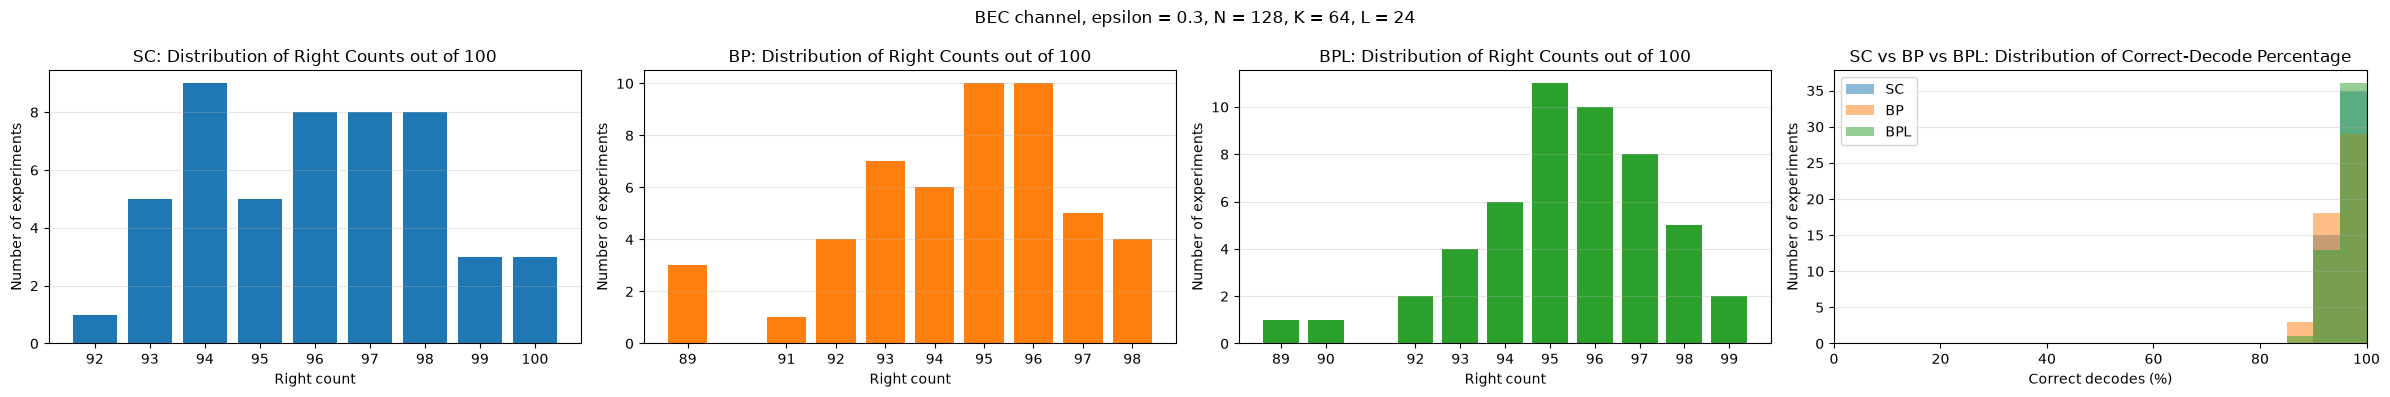

In [5]:
import matplotlib.pyplot as plt
from collections import Counter

colors = {"SC": "tab:blue", "SCL": "tab:red", "BP": "tab:orange", "BPL": "tab:green"}

#*one panel per decoder plus the shared overlay, so adding a decoder to `decoders`
#*above widens this figure without any other edit here
fig, axes = plt.subplots(1, len(results) + 1, figsize=(6 * (len(results) + 1), 4))
fig.suptitle(f"{CHANNEL} channel, {config['param_name']} = {CHANNEL_PARAM}, "
             f"N = {N}, K = {K}, L = {N_GRAPHS}")

for ax, (name, result) in zip(axes, results.items()):
    distribution = Counter(result["right_counts"])
    x = sorted(distribution.keys())
    y = [distribution[count] for count in x]

    ax.bar(x, y, width=0.8, color=colors[name])
    ax.set_xlabel("Right count")
    ax.set_ylabel("Number of experiments")
    ax.set_title(f"{name}: Distribution of Right Counts out of {SAMPLES}")
    ax.set_xticks(x)
    ax.grid(axis="y", alpha=0.3)

#*every decoder now sees the same SAMPLES denominator, so the percentages are directly
#*comparable; the fixed range keeps every bin inside [0, 100] so bars are never cropped
overlay = axes[-1]
for name, result in results.items():
    pct = [count / SAMPLES * 100 for count in result["right_counts"]]
    overlay.hist(pct, bins=20, range=(0, 100), color=colors[name], alpha=0.5, label=name)

overlay.set_xlabel("Correct decodes (%)")
overlay.set_ylabel("Number of experiments")
overlay.set_title(" vs ".join(results) + ": Distribution of Correct-Decode Percentage")
overlay.set_xlim(0, 100)
overlay.grid(axis="y", alpha=0.3)
overlay.legend()

plt.tight_layout()
plt.show()

In [6]:
np.float16(1.0 / 0.0)

ZeroDivisionError: float division by zero

In [ ]:
mat = np.array([[1, 2], [3, 4]])
mat = np.zeros([4, 5])
mat
arr1 = np.array([0, 1, 0])
arr2 = np.array([0, 1, 1])
for u_i, i in enumerate(arr2):
    print(u_i)
(arr1 == arr2).all()

In [ ]:
graph = [[["t", i], ["b", 8 - i]] for i in range(8)]
graph[0]

[['t', 0], ['b', 8]]

In [ ]:
u = [1, 0, 0, 0, 1, 1, 0, 1]
frozen_scratch = bec_frozen_set(16, 8, 0.5)
codeword_scratch = PolarEncoder(PolarCode(16, 8, frozen_scratch)).encode(u)
llrs_scratch = BECChannel(0.5).transmit(codeword_scratch, mode='llrs') #*Log LRs
bp_estimate, bp_ok = bp_decode(frozen_scratch, llrs_scratch, None, 200, True) #*already excludes frozen positions
bpl_estimate, bpl_ok = bpl_decode(frozen_scratch, llrs_scratch, 24, 200, use_gpu=False)
print("BP :", bp_estimate, bp_ok)
print("BPL:", bpl_estimate, bpl_ok)